# Comparison between HistFactory and Gaussian Process Regression

This notebook performs a comparison in a two-dimensional nuisance parameter space between `histosys` modifier that uses HistFactory style interpolation and `gphistosys` modifier which uses Gaussian Process Regression. Our parameter space is:

$$\alpha = (\alpha_1, \alpha_2)$$ 

Note: A single `gphistosys` modifier handles both dimensions without factorization assumptions. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import pyhf

## Common model data

In [2]:
NOM  = [200.0, 80.0]    # nominal background, 2 bins
SIG  = [ 50.0, 30.0]    # signal
# DATA = [260.0, 95.0]    # observed — pulled toward signal
DATA = [200.0, 80.0]    # observed — Asimov

# Templates at basis points — asymmetric variations
A1_HI = [240.0,  88.0]  # (+1,  0) 
A1_LO = [180.0,  77.0]  # (-1,  0) 
A2_HI = [210.0, 100.0]  # ( 0, +1) 
A2_LO = [190.0,  60.0]  # ( 0, -1) 


## 2D interpolation comparisons

Scan the full $\alpha_1, \alpha_2$ plane with $\mu=0$ and plot the expected background yield for each model side-by-side.

## 2D interpolation comparisons

Scan the full $\alpha_1, \alpha_2$ plane with $\mu=0$ and plot the expected background yield for each model side-by-side.

## Build workspaces

In [3]:
def make_histosys2d_ws():
    """Two independent 1D histosys modifiers — separable baseline."""
    return {
        "channels": [{"name": "SR", "samples": [
            {"name": "signal",
             "data": SIG,
             "modifiers": [{"name": "mu", "type": "normfactor", "data": None}]},
            {"name": "background",
             "data": NOM,
             "modifiers": [
                 {"name": "alpha1", "type": "histosys",
                  "data": {"lo_data": A1_LO, "hi_data": A1_HI}},
                 {"name": "alpha2", "type": "histosys",
                  "data": {"lo_data": A2_LO, "hi_data": A2_HI}},
             ]},
        ]}],
        "observations": [{"name": "SR", "data": DATA}],
        "measurements": [{"name": "meas", "config": {"poi": "mu", "parameters": []}}],
        "version": "1.0.0",
    }


def make_gphistosys2d_ws(basis, templates, labels):
    """Single gphistosys modifier with a 2D alpha vector, individually labelled."""
    return {
        "channels": [{"name": "SR", "samples": [
            {"name": "signal",
             "data": SIG,
             "modifiers": [{"name": "mu", "type": "normfactor", "data": None}]},
            {"name": "background",
             "data": NOM,
             "modifiers": [
                 {"name": "alpha",
                  "type": "gphistosys_additive",
                  "data": {"nodes": basis, 
                           "templates": templates, 
                           "labels": labels}},
             ]},
        ]}],
        "observations": [{"name": "SR", "data": DATA}],
        "measurements": [{"name": "meas", "config": {"poi": "mu", "parameters": []}}],
        "version": "1.0.0",
    }


modifier_set = pyhf.modifiers.histfactory_set

# --- histosys baseline ---
histo_model = pyhf.Workspace(make_histosys2d_ws()).model(
    modifier_set=modifier_set,
    modifier_settings={'histosys': {'interpcode': 'code4p'}},
)

# --- gphistosys 2D: 5 nodes, labels expose each dimension as a named parameter ---
basis = [
    [ 1.0,  0.0],   # alpha1 up
    [-1.0,  0.0],   # alpha1 down
    [ 0.0,  1.0],   # alpha2 up
    [ 0.0, -1.0],   # alpha2 down
]
templates = [A1_HI, A1_LO, A2_HI, A2_LO]
labels    = ["alpha1", "alpha2"]   # pyhf parameter names for each GP dimension

gp_model = pyhf.Workspace(make_gphistosys2d_ws(basis, templates, labels)).model(
    modifier_set=modifier_set,
    modifier_settings={'gphistosys': {'length_scale': 10.0, 'noise': 0.0}},
    validate=False,
)

print('par order (histosys):', histo_model.config.par_order)
print('par order (gphistosys):', gp_model.config.par_order)

par order (histosys): ['alpha1', 'alpha2', 'mu']
par order (gphistosys): ['alpha1', 'alpha2', 'mu']


## 2D interpolation comparisons

Scan the full $\alpha_1, \alpha_2$ plane with $\mu=0$ and plot the expected background yield for each model side-by-side.

In [4]:
grid_pts = 40
a_vals = np.linspace(-2.0, 2.0, grid_pts)
A1, A2 = np.meshgrid(a_vals, a_vals)


def sweep_2d(model, A1, A2, mu=0.0, a1_name='alpha1', a2_name='alpha2'):
    """Evaluate expected background yield over a 2D alpha grid.

    Returns array of shape (grid, grid, n_bins).
    """
    grid = A1.shape[0]
    mu_idx  = model.config.par_map['mu']['slice'].start
    a1_idx  = model.config.par_map[a1_name]['slice'].start
    a2_idx  = model.config.par_map[a2_name]['slice'].start
    out = np.zeros((grid, grid, 2))

    for i in range(grid):
        for j in range(grid):
            pars = np.array(model.config.suggested_init())
            pars[mu_idx] = mu
            pars[a1_idx] = A1[i, j]
            pars[a2_idx] = A2[i, j]
            out[i, j] = model.expected_actualdata(pars)
    return out


Y_histo = sweep_2d(histo_model, A1, A2)
Y_gp    = sweep_2d(gp_model,    A1, A2)

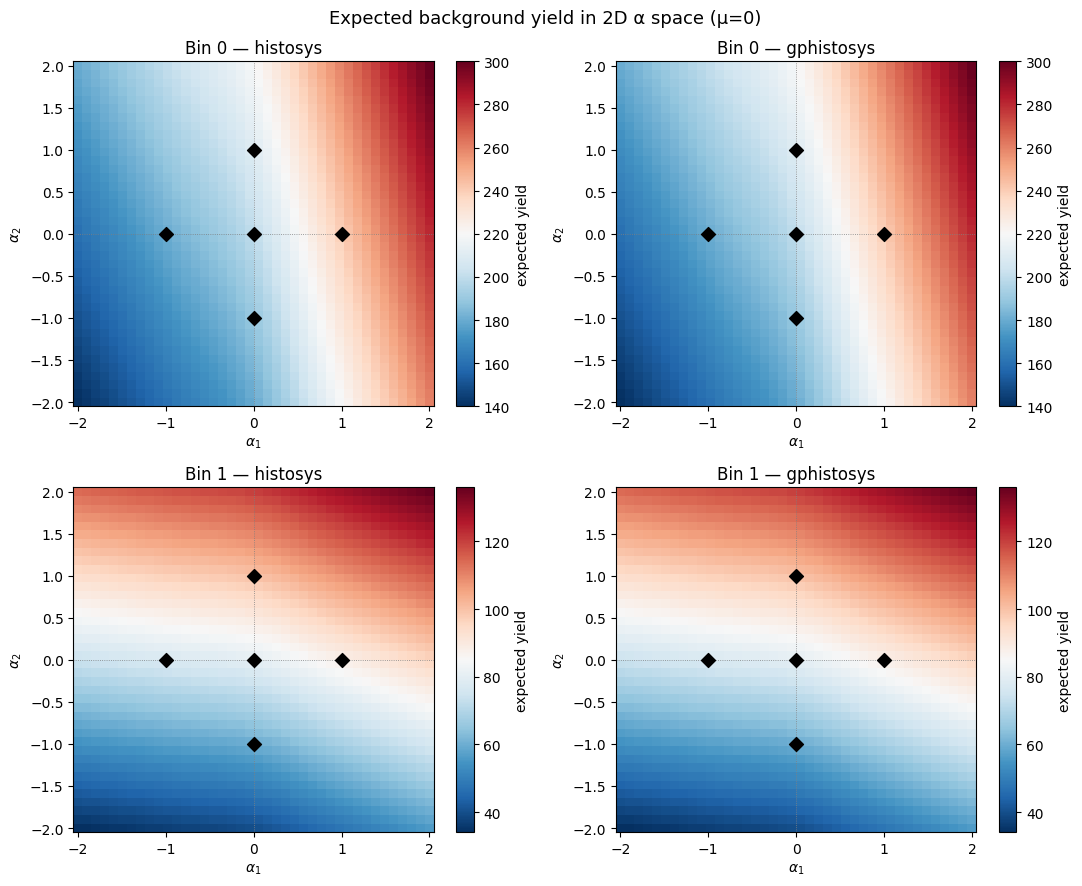

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

for bin_idx, row in enumerate(axes):
    vmin = min(Y_histo[:, :, bin_idx].min(), Y_gp[:, :, bin_idx].min())
    vmax = max(Y_histo[:, :, bin_idx].max(), Y_gp[:, :, bin_idx].max())

    for ax, Y, title in zip(row,
                             [Y_histo, Y_gp],
                             ['histosys', 'gphistosys']):
        im = ax.pcolormesh(A1, A2, Y[:, :, bin_idx],
                           cmap='RdBu_r', vmin=vmin, vmax=vmax, shading='auto')
        fig.colorbar(im, ax=ax, label='expected yield')

        # Mark anchor basis
        node_a1 = [0, 1, -1, 0,  0]
        node_a2 = [0, 0,  0, 1, -1]
        ax.scatter(node_a1, node_a2, c='k', s=50, zorder=5, marker='D')

        ax.axhline(0, color='grey', lw=0.6, ls=':')
        ax.axvline(0, color='grey', lw=0.6, ls=':')
        ax.set_xlabel(r'$\alpha_1$')
        ax.set_ylabel(r'$\alpha_2$')
        ax.set_title(f'Bin {bin_idx} — {title}')

plt.suptitle('Expected background yield in 2D α space (μ=0)', fontsize=13)
plt.tight_layout()
plt.show()

## Axis slice comparison

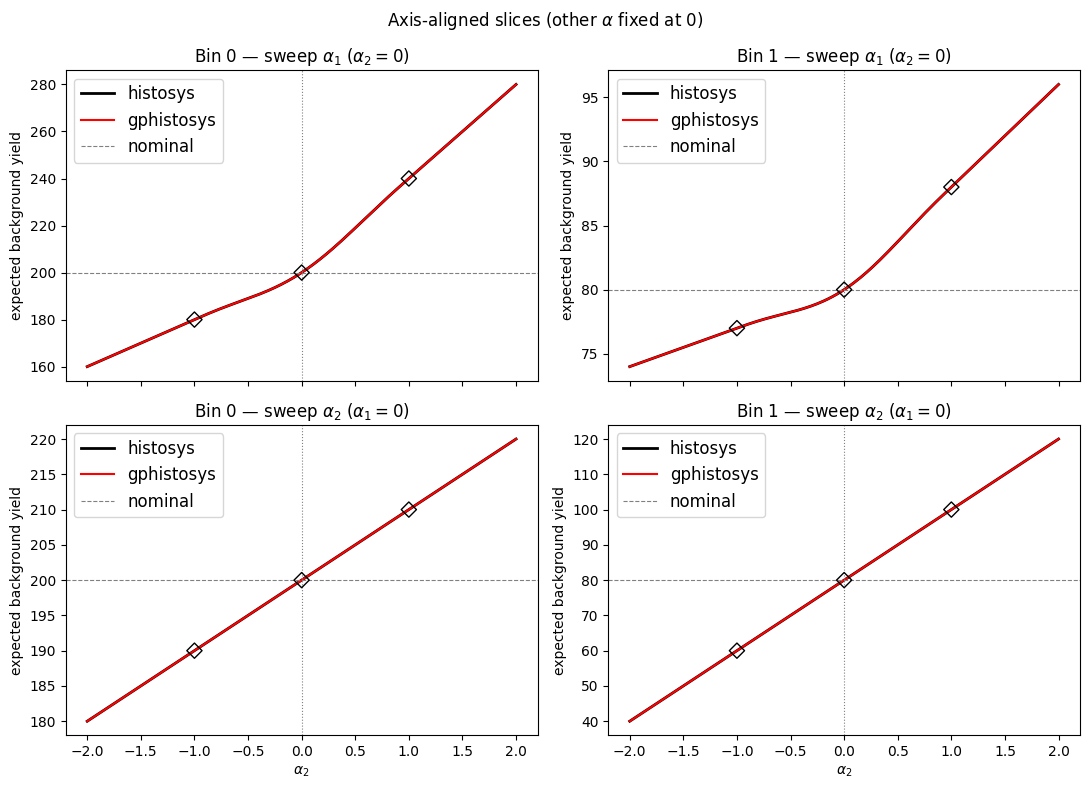

In [19]:
scan_vals = np.linspace(-2.0, 2.0, 200)


def sweep_axis(model, scan_vals, scan_name, fixed_name, fixed_val=0.0, mu=0.0):
    """Sweep one alpha while holding the other fixed."""
    mu_idx   = model.config.par_map['mu']['slice'].start
    scan_idx = model.config.par_map[scan_name]['slice'].start
    fix_idx  = model.config.par_map[fixed_name]['slice'].start
    out = []
    for a in scan_vals:
        pars = np.array(model.config.suggested_init())
        pars[mu_idx]   = mu
        pars[scan_idx] = a
        pars[fix_idx]  = fixed_val
        out.append(model.expected_actualdata(pars))
    return np.array(out)


# 2 rows (one per scanned alpha) x 2 cols (one per bin).
alpha_pairs = [('alpha1', 'alpha2'), ('alpha2', 'alpha1')]
n_bins      = len(NOM)
basis_lo = {'alpha1': A1_LO, 'alpha2': A2_LO}
basis_hi = {'alpha1': A1_HI, 'alpha2': A2_HI}

fig, axes = plt.subplots(len(alpha_pairs), n_bins, figsize=(11, 8), sharex=True)

for row, (scan_name, fixed_name) in enumerate(alpha_pairs):
    y_h = sweep_axis(histo_model, scan_vals, scan_name, fixed_name)
    y_g = sweep_axis(gp_model,    scan_vals, scan_name, fixed_name)
    
    for bin_idx in range(n_bins):
        ax = axes[row, bin_idx]
        ax.plot(scan_vals, y_h[:, bin_idx], 'k-', lw=2,   label='histosys')
        ax.plot(scan_vals, y_g[:, bin_idx], 'r-', lw=1.5, label='gphistosys')
        ax.axvline(0, color='grey', lw=0.8, ls=':')
        ax.axhline(NOM[bin_idx], color='grey', lw=0.8, ls='--', label='nominal')
        if row == len(alpha_pairs) - 1:
            ax.set_xlabel(rf'$\{scan_name[:-1]}_{scan_name[-1]}$')
        ax.set_ylabel('expected background yield')
        ax.set_title(rf'Bin {bin_idx} — sweep $\{scan_name[:-1]}_{scan_name[-1]}$ '
                     rf'($\{fixed_name[:-1]}_{fixed_name[-1]} = 0$)')
        ax.legend(fontsize=12)
        ax.scatter(
            [-1, 0, +1],
            [basis_lo[scan_name][bin_idx], NOM[bin_idx], basis_hi[scan_name][bin_idx]],
            marker='D', s=60, facecolor='none', edgecolor='black',
            zorder=5, label='basis',
        )


plt.suptitle(r'Axis-aligned slices (other $\alpha$ fixed at 0)', fontsize=12)
plt.tight_layout()
plt.show()


## Diagonal slice comparison

To make the difference concrete, sweep along the diagonal $\alpha_1 = \alpha_2$ and compare the two models bin by bin. 

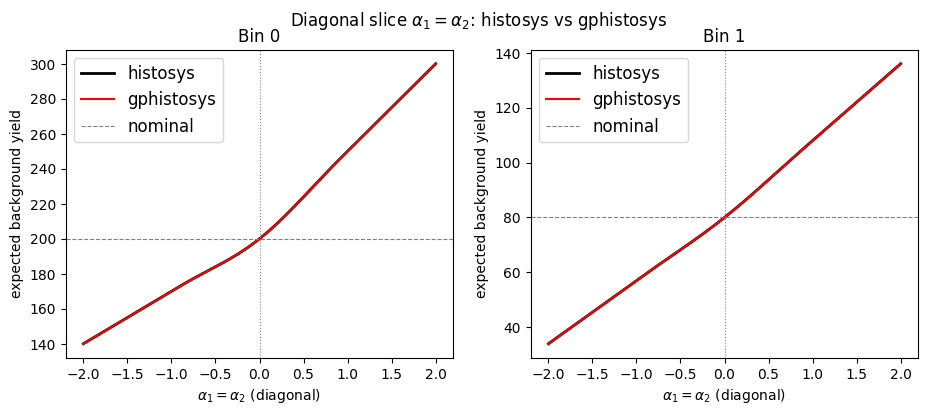

In [15]:
diag_vals = np.linspace(-2.0, 2.0, 200)


def sweep_diagonal(model, diag_vals, mu=0.0, a1_name='alpha1', a2_name='alpha2'):
    """Sweep along the diagonal $\alpha_1 = \alpha_2$."""
    mu_idx = model.config.par_map['mu']['slice'].start
    a1_idx = model.config.par_map[a1_name]['slice'].start
    a2_idx = model.config.par_map[a2_name]['slice'].start
    out = []
    for a in diag_vals:
        pars = np.array(model.config.suggested_init())
        pars[mu_idx] = mu
        pars[a1_idx] = a
        pars[a2_idx] = a
        out.append(model.expected_actualdata(pars))
    return np.array(out)


y_histo_diag = sweep_diagonal(histo_model, diag_vals)
y_gp_diag    = sweep_diagonal(gp_model,    diag_vals)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for bin_idx, ax in enumerate(axes):
    ax.plot(diag_vals, y_histo_diag[:, bin_idx], 'k-',  lw=2,   label='histosys')
    ax.plot(diag_vals, y_gp_diag   [:, bin_idx], 'r-',  lw=1.5, label='gphistosys')
    ax.axvline(0, color='grey', lw=0.8, ls=':')
    ax.axhline(NOM[bin_idx], color='grey', lw=0.8, ls='--', label='nominal')
    ax.set_xlabel(r'$\alpha_1 = \alpha_2$ (diagonal)')
    ax.set_ylabel('expected background yield')
    ax.set_title(f'Bin {bin_idx}')
    ax.legend(fontsize=12)

plt.suptitle(r'Diagonal slice $\alpha_1 = \alpha_2$: histosys vs gphistosys', fontsize=12)
plt.show()

## Fit comparison

In [8]:
obs_histo = DATA + histo_model.config.auxdata
obs_gp    = DATA + gp_model.config.auxdata

pars_histo, nll_histo = pyhf.infer.mle.fit(obs_histo, histo_model, return_fitted_val=True)
pars_gp,    nll_gp    = pyhf.infer.mle.fit(obs_gp,    gp_model,    return_fitted_val=True)


def print_result(label, pars, nll, model):
    print(f'{label}  (2*NLL = {float(nll):.4f})')
    for name, val in zip(model.config.par_order, pars):
        print(f'  {name:15s} = {float(val):+.4f}')
    print()


print_result('histosys ', pars_histo, nll_histo, histo_model)
print_result('gphistosys',   pars_gp,    nll_gp,    gp_model)

histosys   (2*NLL = 17.0348)
  alpha1          = -0.0003
  alpha2          = -0.0001
  mu              = +0.0002

gphistosys  (2*NLL = 17.0348)
  alpha1          = -0.0003
  alpha2          = -0.0001
  mu              = +0.0002



## Profile NLL curves

In [9]:
from scipy.optimize import minimize

mu_scan    = np.linspace(0.0, 2.5, 80)
alpha_scan = np.linspace(-2.5, 2.5, 80)

# Both models now share the same parameter names: alpha1, alpha2, mu
def par_idx(model, name):
    return model.config.par_map[name]['slice'].start

h_mu_idx = histo_model.config.poi_index
h_a1_idx = par_idx(histo_model, 'alpha1')
h_a2_idx = par_idx(histo_model, 'alpha2')

gp_mu_idx = gp_model.config.poi_index
gp_a1_idx = par_idx(gp_model, 'alpha1')
gp_a2_idx = par_idx(gp_model, 'alpha2')


# --- profile NLL vs mu: pyhf native ---
def profile_nll_mu(model, obs, mu_vals):
    """Profile NLL vs mu using pyhf.infer.mle.fixed_poi_fit."""
    nll_min = pyhf.infer.mle.fit(obs, model, return_fitted_val=True)[1].item()
    bounds = list(model.config.suggested_bounds())
    bounds[model.config.poi_index] = (min(mu_vals) - 0.1, max(mu_vals) + 0.1)
    nlls = [
        pyhf.infer.mle.fixed_poi_fit(
            mu, obs, model,
            init_pars=[mu if i == model.config.poi_index else v
                       for i, v in enumerate(model.config.suggested_init())],
            par_bounds=bounds,
            return_fitted_val=True,
        )[1].item()
        for mu in mu_vals
    ]
    return np.array(nlls) - nll_min


# --- profile NLL vs a nuisance param: no pyhf equivalent, use scipy ---
# pyhf.infer.mle.fixed_poi_fit only fixes the designated POI (mu).
# To fix an arbitrary nuisance parameter we minimise twice_nll directly.
def profile_nll_alpha_1d(model, obs, alpha_vals, fixed_par, free_pars):
    """Profile NLL scanning one nuisance parameter, minimising over all others."""
    nll_min = pyhf.infer.mle.fit(obs, model, return_fitted_val=True)[1].item()
    x0 = [model.config.suggested_init()[i] for i in free_pars]
    results = []
    for a in alpha_vals:
        def obj(x, _a=a):
            pars = np.array(model.config.suggested_init())
            pars[fixed_par] = _a
            for idx, val in zip(free_pars, x):
                pars[idx] = val
            return pyhf.infer.mle.twice_nll(pars, obs, model).item()
        res = minimize(obj, x0, method='Nelder-Mead',
                       options={'xatol': 1e-5, 'fatol': 1e-5, 'maxiter': 2000})
        results.append(res.fun - nll_min)
    return np.array(results)


print('Computing profile NLL vs mu...')
qmu_histo = profile_nll_mu(histo_model, obs_histo, mu_scan)
qmu_gp    = profile_nll_mu(gp_model,    obs_gp,    mu_scan)

print('Computing profile NLL vs alpha1...')
qa1_histo = profile_nll_alpha_1d(histo_model, obs_histo, alpha_scan,
                                  fixed_par=h_a1_idx,  free_pars=[h_mu_idx,  h_a2_idx])
qa1_gp    = profile_nll_alpha_1d(gp_model,    obs_gp,   alpha_scan,
                                  fixed_par=gp_a1_idx, free_pars=[gp_mu_idx, gp_a2_idx])

print('Computing profile NLL vs alpha2...')
qa2_histo = profile_nll_alpha_1d(histo_model, obs_histo, alpha_scan,
                                  fixed_par=h_a2_idx,  free_pars=[h_mu_idx,  h_a1_idx])
qa2_gp    = profile_nll_alpha_1d(gp_model,    obs_gp,   alpha_scan,
                                  fixed_par=gp_a2_idx, free_pars=[gp_mu_idx, gp_a1_idx])

print('Done.')

Computing profile NLL vs mu...
Computing profile NLL vs alpha1...
Computing profile NLL vs alpha2...
Done.


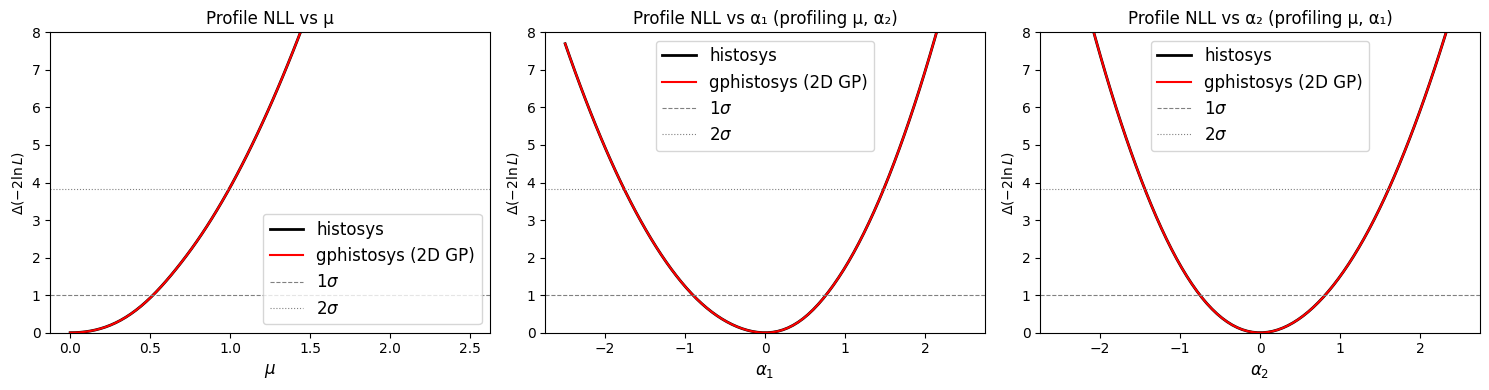

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

scan_data = [
    (axes[0], mu_scan,    qmu_histo, qmu_gp,    r'$\mu$',          'Profile NLL vs μ'),
    (axes[1], alpha_scan, qa1_histo, qa1_gp,    r'$\alpha_1$',     r'Profile NLL vs α₁ (profiling μ, α₂)'),
    (axes[2], alpha_scan, qa2_histo, qa2_gp,    r'$\alpha_2$',     r'Profile NLL vs α₂ (profiling μ, α₁)'),
]

for ax, xvals, q_h, q_gp, xlabel, title in scan_data:
    ax.plot(xvals, q_h,  'k-',  lw=2,   label='histosys')
    ax.plot(xvals, q_gp, 'r-',  lw=1.5, label='gphistosys (2D GP)')
    ax.axhline(1.0,  color='grey', lw=0.8, ls='--', label=r'$1\sigma$')
    ax.axhline(3.84, color='grey', lw=0.8, ls=':',  label=r'$2\sigma$')
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(r'$\Delta(-2\ln L)$')
    ax.set_ylim(0, 8)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

## 2D NLL contour

Scan the $(\alpha_1, \alpha_2)$ plane and compute the 2NLL at each point with μ fixed to its
best-fit value.  The contours reveal the shape of the nuisance parameter
constraint and how the GP correlates the two dimensions.

In [11]:
grid_n = 30
a_grid = np.linspace(-2.5, 2.5, grid_n)
AG1, AG2 = np.meshgrid(a_grid, a_grid)

mu_hat_histo = pars_histo[h_mu_idx].item()
mu_hat_gp    = pars_gp[gp_mu_idx].item()


def nll_grid_2d(model, obs, mu_fixed, a1_idx, a2_idx, AG1, AG2, nll_min):
    """Evaluate twice_nll on a 2D grid with mu and both alphas fixed."""
    Z = np.zeros_like(AG1)
    for i in range(AG1.shape[0]):
        for j in range(AG1.shape[1]):
            pars = np.array(model.config.suggested_init())
            pars[model.config.poi_index] = mu_fixed
            pars[a1_idx] = AG1[i, j]
            pars[a2_idx] = AG2[i, j]
            Z[i, j] = pyhf.infer.mle.twice_nll(pars, obs, model).item() - nll_min
    return Z


Z_histo = nll_grid_2d(histo_model, obs_histo, mu_hat_histo,
                       h_a1_idx, h_a2_idx, AG1, AG2, nll_histo.item())
Z_gp    = nll_grid_2d(gp_model,    obs_gp,    mu_hat_gp,
                       gp_a1_idx, gp_a2_idx, AG1, AG2, nll_gp.item())


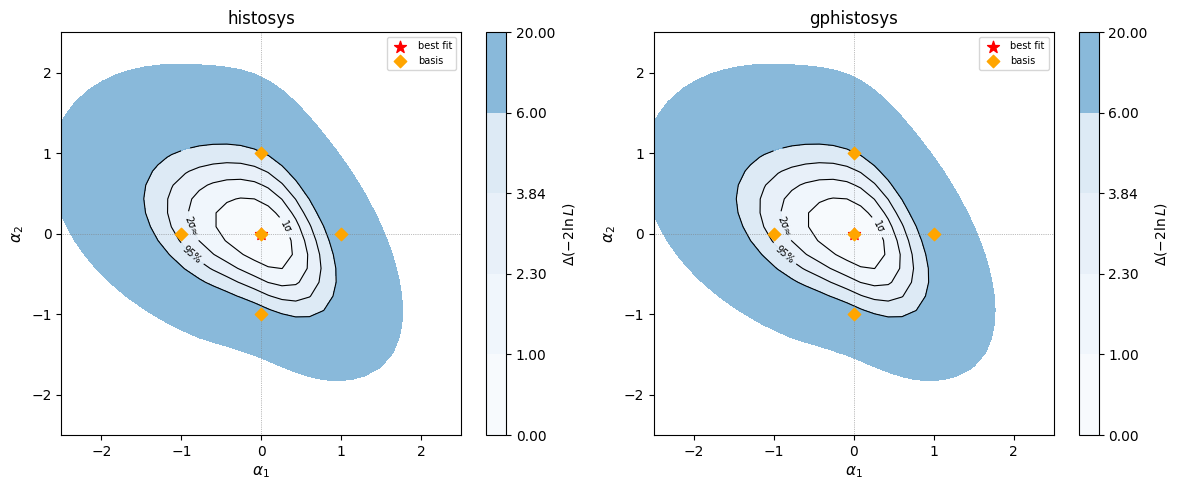

In [12]:
levels = [1.0, 2.3, 3.84, 6.0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for ax, Z, title, pars_fit, a1_idx, a2_idx in [
    (ax1, Z_histo, 'histosys',   pars_histo, h_a1_idx,  h_a2_idx),
    (ax2, Z_gp,   'gphistosys',  pars_gp,    gp_a1_idx, gp_a2_idx),
]:
    cf = ax.contourf(AG1, AG2, Z, levels=[0] + levels + [20],
                     cmap='Blues', alpha=0.6)
    cs = ax.contour(AG1, AG2, Z, levels=levels,
                    colors='k', linewidths=0.8)
    ax.clabel(cs, fmt={1.0: '1σ', 2.3: '2σ≈', 3.84: '95%', 6.0: ''}, fontsize=7)
    fig.colorbar(cf, ax=ax, label=r'$\Delta(-2\ln L)$')

    ax.scatter([pars_fit[a1_idx].item()], [pars_fit[a2_idx].item()],
               c='red', s=80, zorder=5, marker='*', label='best fit')
    ax.scatter([0, 1, -1, 0,  0], [0, 0,  0, 1, -1],
               c='orange', s=40, zorder=5, marker='D', label='basis')

    ax.axhline(0, color='grey', lw=0.5, ls=':')
    ax.axvline(0, color='grey', lw=0.5, ls=':')
    ax.set_xlabel(r'$\alpha_1$', fontsize=11)
    ax.set_ylabel(r'$\alpha_2$', fontsize=11)
    ax.set_title(title)
    ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()
